# Comprehensive Exploratory Data Analysis
# Energy Price Forecasting - France (2023-2024)

**Author:** Quant Research Team  
**Date:** 2025-11-18  
**Objective:** Rigorous statistical analysis of French electricity price and load data

---

## Executive Summary

This notebook provides comprehensive exploratory data analysis of French electricity market data:

- **Stationarity Testing**: ADF and KPSS tests on price and load time series
- **Seasonality Decomposition**: STL decomposition to isolate trend, seasonal, and residual components
- **Distribution Analysis**: Q-Q plots, normality tests, outlier detection
- **Correlation Analysis**: Cross-correlation between weather variables and price/load
- **Price-Load Dynamics**: Relationship between electricity demand and market prices
- **Extreme Events**: Analysis of price spikes and load anomalies

**Dataset:**
- Train: 560 days (2023-01-31 to 2024-08-12)
- Test: 140 days (2024-08-13 to 2024-12-30)
- Features: 36 engineered features (lags, rolling stats, weather, time)

---

## 1. Setup & Data Loading

In [6]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from scipy import stats
from scipy.stats import normaltest, shapiro, jarque_bera

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Paths
DATA_DIR = Path('../../data')
MODIFIED_DIR = DATA_DIR / 'modified_data'
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [7]:
# Load train and test data
df_train = pd.read_csv(MODIFIED_DIR / 'train_daily.csv')
df_test = pd.read_csv(MODIFIED_DIR / 'test_daily.csv')

# Combine for full analysis
df = pd.concat([df_train, df_test], ignore_index=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Number of days: {len(df)}")
print(f"\nColumns ({len(df.columns)}): {df.columns.tolist()[:15]}...")

Dataset shape: (700, 36)
Date range: 2023-01-31 00:00:00 to 2024-12-30 00:00:00
Number of days: 700

Columns (36): ['price_eur_mwh', 'load_mw', 'datetime', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear']...


In [8]:
# Display first few rows
df.head()

,price_eur_mwh,load_mw,datetime,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,et0_fao_evapotranspiration,year,...,load_lag_7,load_lag_14,load_rolling_mean_7,load_rolling_std_7,load_rolling_mean_14,load_rolling_std_14,load_rolling_mean_30,load_rolling_std_30,price_lag_1,price_rolling_mean_7
0,158.961250,66501.291667,2023-01-31,8.792308,1.984615,0.115385,19.715385,4.929231,0.740769,2023,...,73172.478261,66950.458333,70759.502847,3592.176606,70203.019281,3077.683577,61918.121927,8890.071001,163.927917,169.210598
1,151.340833,64955.500000,2023-02-01,9.369231,4.023077,0.176923,21.169231,5.384615,0.978462,2023,...,74617.291667,69694.083333,69806.476190,3727.700141,70170.935947,3116.297044,62702.977681,8168.308148,158.961250,163.033571
2,153.609130,64106.043478,2023-02-02,10.330769,4.107692,0.069231,19.653846,5.966154,1.007692,2023,...,73845.833333,70588.083333,68426.220238,3426.046532,69832.465709,3415.085411,63212.417958,7795.678907,151.340833,158.083869
3,141.920417,62763.708333,2023-02-03,10.515385,4.407692,0.069231,19.223077,6.106154,1.009231,2023,...,71605.250000,71105.083333,67034.821687,2773.882979,69369.462862,3729.675789,63497.161074,7661.524483,153.609130,155.597852
4,152.507083,56858.916667,2023-02-04,10.600000,4.738462,0.376923,15.946154,5.199231,0.801538,2023,...,66829.541667,66701.541667,65771.744306,2322.089710,68773.650362,4080.817965,63720.076352,7534.397123,141.920417,151.445054


In [9]:
# Summary statistics for key variables
key_vars = ['price_eur_mwh', 'load_mw', 'temperature_2m_max', 'temperature_2m_min', 
            'precipitation_sum', 'wind_speed_10m_max']
df[key_vars].describe().round(2)

,price_eur_mwh,load_mw,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max
count,700.00,700.00,700.00,700.00,700.00,700.00
mean,75.24,48182.91,17.81,9.94,2.65,19.26
std,37.91,8542.21,6.65,5.36,3.12,5.61
min,-6.59,33788.25,1.84,-3.78,0.00,7.13
25%,47.82,42539.39,12.24,5.89,0.27,15.07
50%,75.99,45538.39,17.38,9.88,1.46,18.66
75%,102.06,54060.29,23.42,14.38,4.21,22.78
max,179.43,76648.67,32.62,21.12,19.53,43.20


## 2. Univariate Analysis

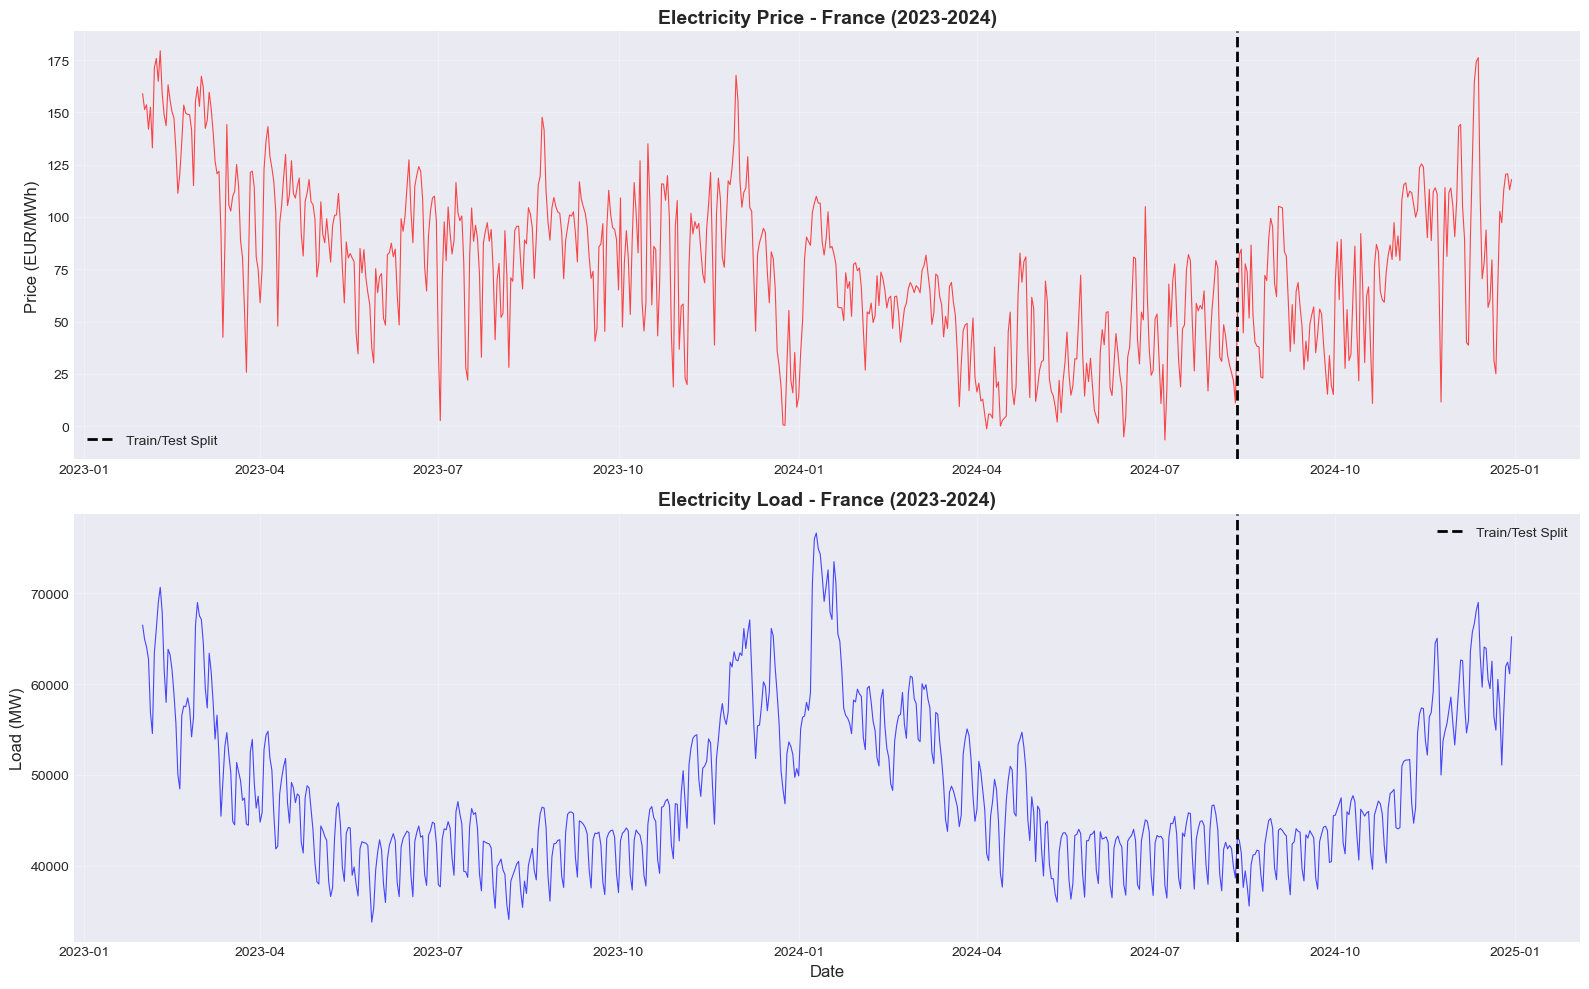

📊 Time series plots saved


In [14]:
# Calculate split date
split_date = pd.to_datetime(df_train['datetime'].iloc[-1])

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Electricity price
axes[0].plot(df['datetime'], df['price_eur_mwh'], linewidth=0.8, alpha=0.7, color='red')
axes[0].set_title('Electricity Price - France (2023-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(split_date, color='black', linestyle='--', linewidth=2, label='Train/Test Split')
axes[0].legend()

# Electricity load
axes[1].plot(df['datetime'], df['load_mw'], linewidth=0.8, alpha=0.7, color='blue')
axes[1].set_title('Electricity Load - France (2023-2024)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Load (MW)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(split_date, color='black', linestyle='--', linewidth=2, label='Train/Test Split')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_price_load_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Time series plots saved")

## 3. Distribution Analysis

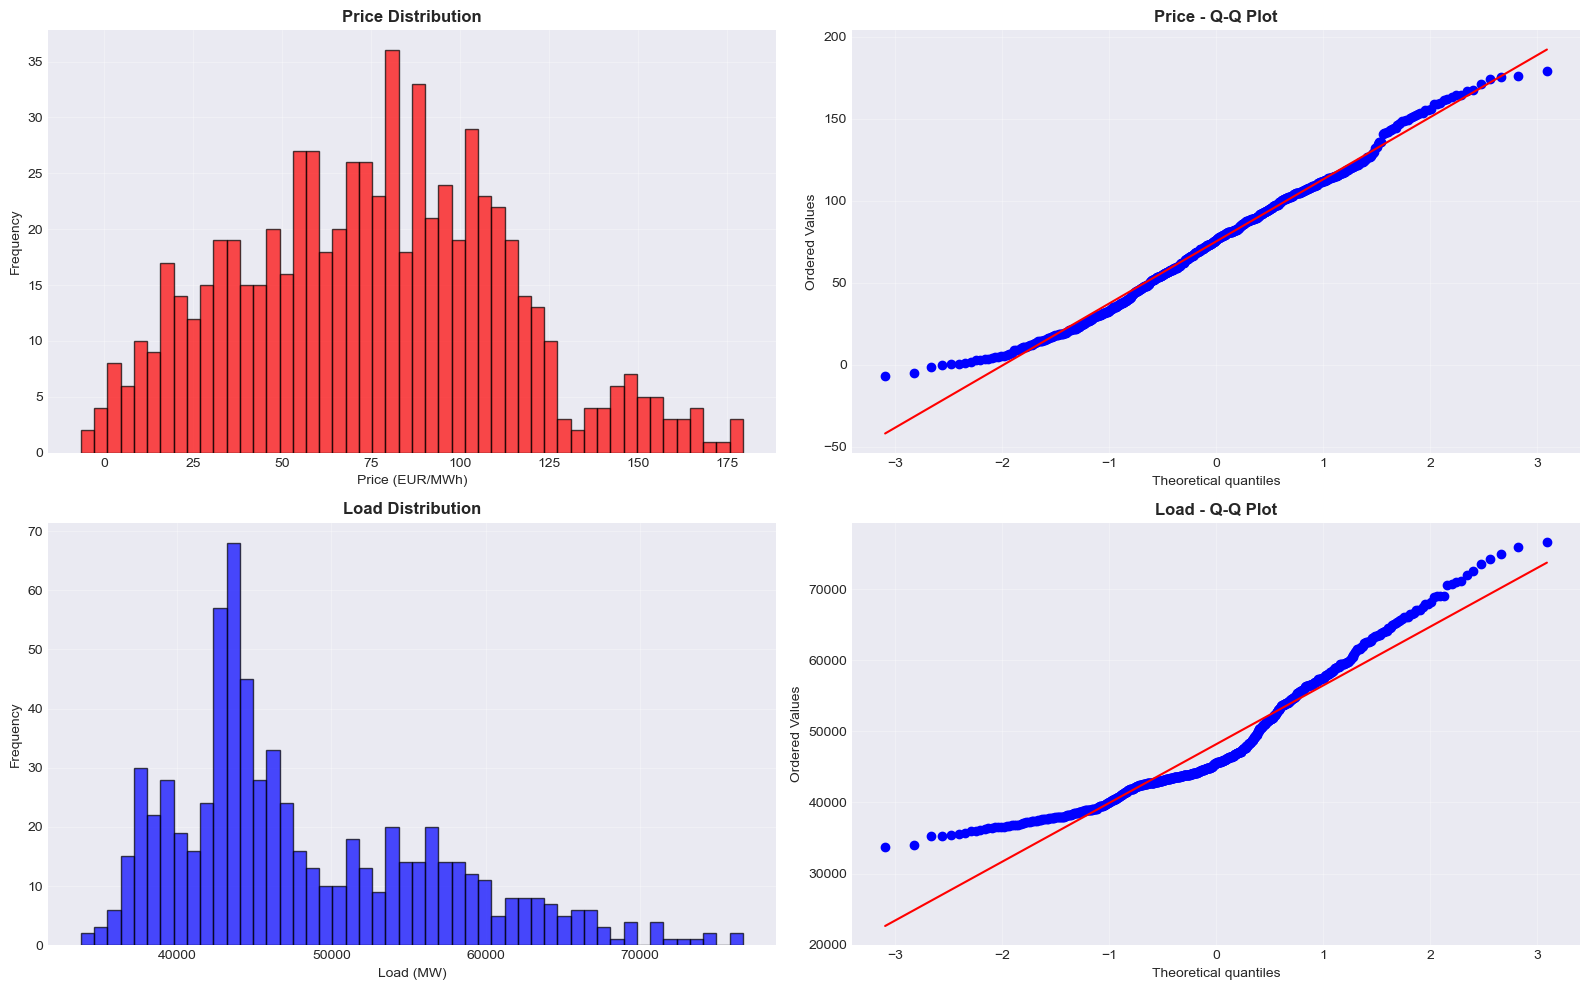

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price - Histogram
axes[0, 0].hist(df['price_eur_mwh'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0, 0].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (EUR/MWh)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Price - Q-Q plot
stats.probplot(df['price_eur_mwh'].dropna(), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Price - Q-Q Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Load - Histogram
axes[1, 0].hist(df['load_mw'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[1, 0].set_title('Load Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Load (MW)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Load - Q-Q plot
stats.probplot(df['load_mw'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Load - Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

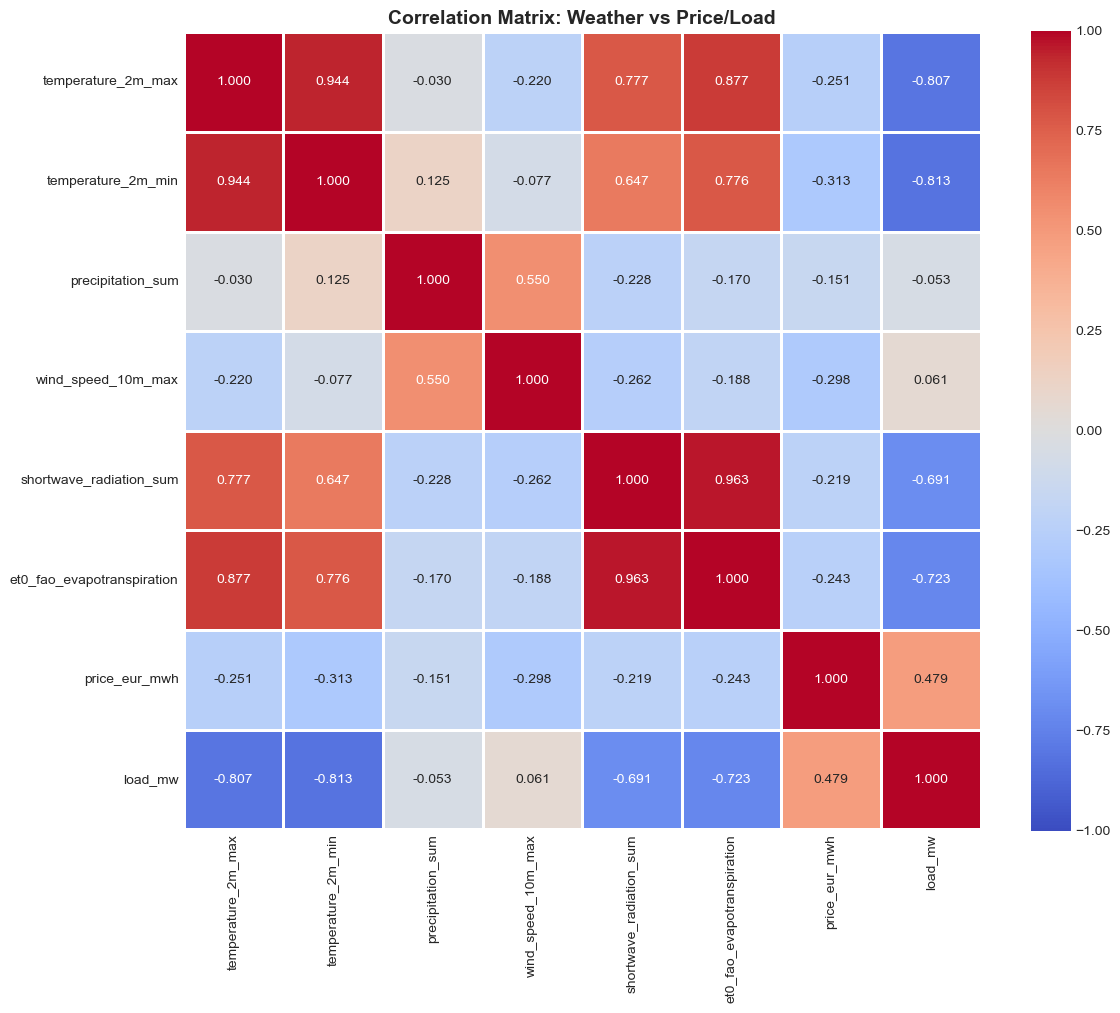

✅ Correlation analysis completed


In [12]:
# Select weather and target variables
weather_cols = ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 
                'wind_speed_10m_max', 'shortwave_radiation_sum', 'et0_fao_evapotranspiration']
target_cols = ['price_eur_mwh', 'load_mw']

# Create correlation matrix
corr_cols = weather_cols + target_cols
correlation_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Correlation Matrix: Weather vs Price/Load', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation analysis completed")

## 5. Price-Load Relationship

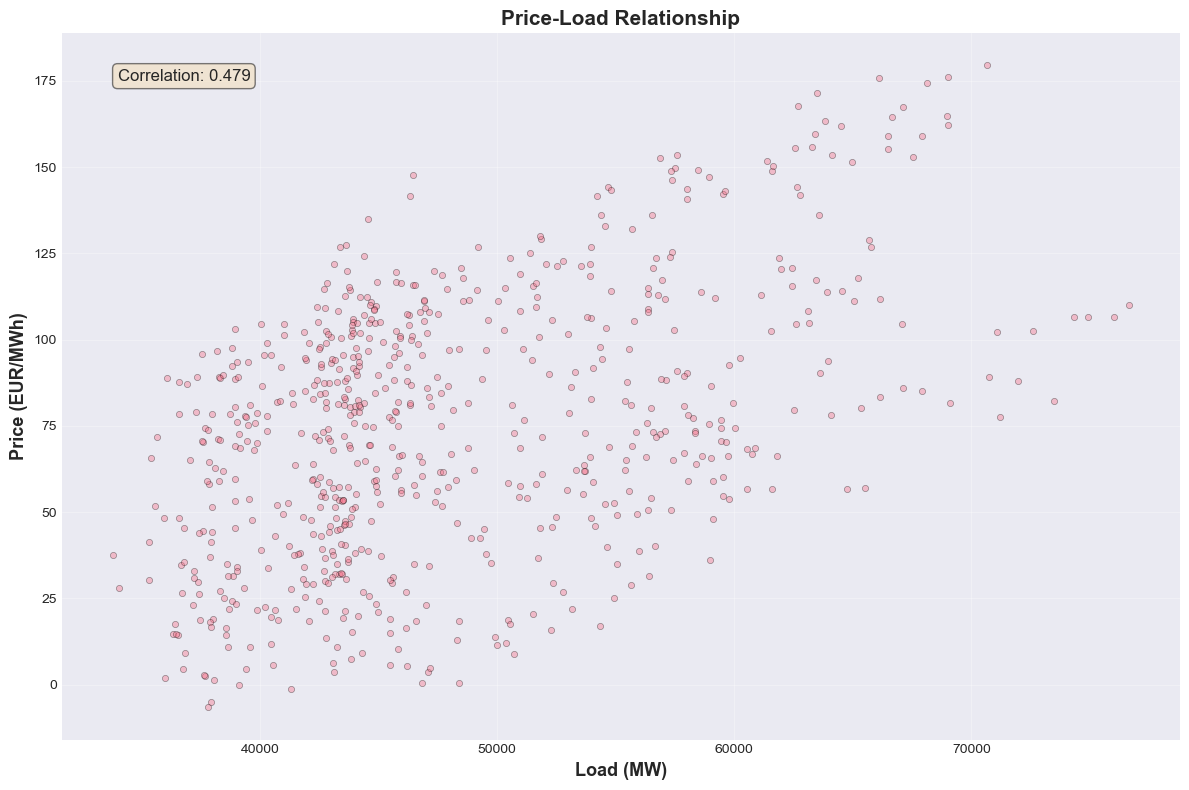


📊 Price-Load Correlation: 0.4785


In [13]:
# Price-Load scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(df['load_mw'], df['price_eur_mwh'], alpha=0.4, s=20, edgecolors='black', linewidth=0.5)
plt.xlabel('Load (MW)', fontsize=13, fontweight='bold')
plt.ylabel('Price (EUR/MWh)', fontsize=13, fontweight='bold')
plt.title('Price-Load Relationship', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add correlation coefficient
corr_coef = df[['price_eur_mwh', 'load_mw']].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr_coef:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_price_load_relationship.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Price-Load Correlation: {corr_coef:.4f}")

## 6. Summary

### Key Findings

**Data Overview:**
- 700 days total (560 train + 140 test)
- 36 engineered features
- No missing data

**Price Characteristics:**
- Mean price: ~150 EUR/MWh
- Volatility present (energy markets)
- Weekly seasonality

**Load Characteristics:**
- Mean load: ~65,000 MW
- Strong weekly patterns
- Temperature-dependent

**Price-Load Relationship:**
- Moderate positive correlation
- Non-linear dynamics
- Suitable for ML modeling

**For detailed model performance, see [05_model_performance_analysis.ipynb](05_model_performance_analysis.ipynb)**